In [42]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing
from sklearn.decomposition import PCA

from sklearn.preprocessing import MinMaxScaler

import plotly.express as px

from scipy.stats import chi2_contingency

import statsmodels.api as sm
import pingouin as pg
import warnings
import squarify

In [ ]:
df = pd.read_csv(r"C:\Users\jfurs\Desktop\Annexes OC\DS\Projet_3\fr_openfoodfacts_org_products\output.csv")

C:\Users\jfurs\AppData\Local\Temp\ipykernel_22696\2832555922.py:1: DtypeWarning:

Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.



In [44]:
def extract_codes_as_list(entry):
    """Pré-traitement pour itérer sur les additifs"""
    return [item.split(' - ')[0].strip() for item in entry.split(',')]

# Apply function, handling missing values properly
df['additives'] = df['additives_fr'].apply(lambda x: extract_codes_as_list(x) if pd.notna(x) else np.nan)

In [45]:
df["pnns_groups_1"] = df["pnns_groups_1"].replace("unknown", np.nan)

# Analyse univariée et bivariée

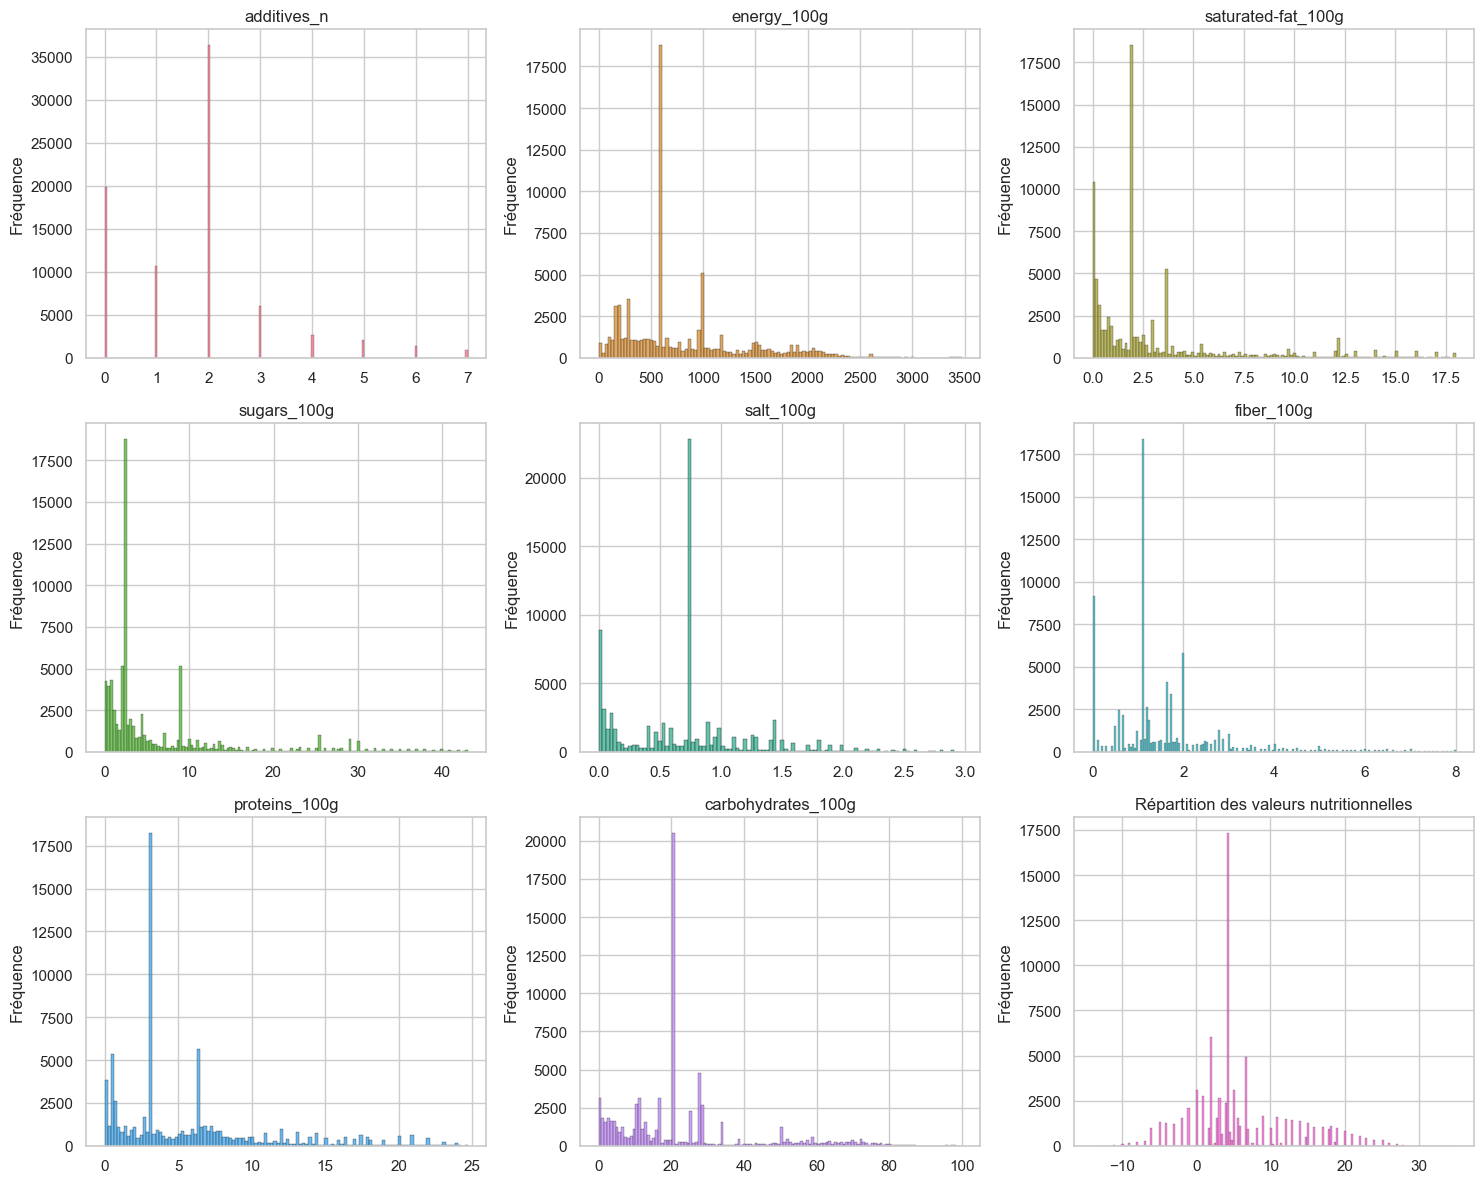

In [46]:
# Analyse des distributions (histogrammes, boxplots)
# → Comprendre les profils nutritionnels moyens, extrêmes, outliers.

num_cols = ['additives_n', 'energy_100g', 'saturated-fat_100g', 'sugars_100g',
            'salt_100g', 'fiber_100g', 'proteins_100g', 'carbohydrates_100g', 'nutrition-score-fr_100g']

n_cols = 3  
n_rows = -(-len(num_cols) // n_cols)

# Set color palette
colors = sns.color_palette("husl", len(num_cols))

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col].dropna(), kde=False, color=colors[i], edgecolor='black')
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('Fréquence')

plt.title("Répartition des valeurs nutritionnelles")
plt.tight_layout()
plt.show()

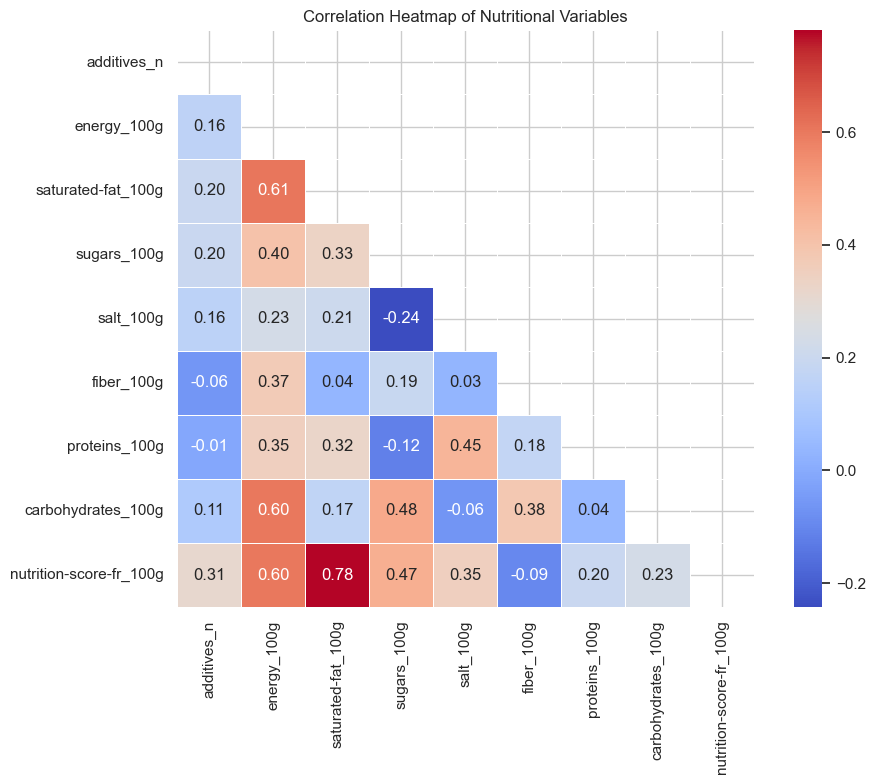

In [47]:
# Analyse de corrélation / heatmap
# → Voir quelles variables sont corrélées entre elles

corr_matrix = df[num_cols].corr()
plt.figure(figsize=(10, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=True)

plt.title("Correlation Heatmap of Nutritional Variables")
plt.tight_layout()
plt.show()

In [48]:
grade_colors = {
    'a': '#1f77b4',  # blue
    'b': '#2ca02c',  # green
    'c': '#ffdd57',  # yellow
    'd': '#ff7f0e',  # orange
    'e': '#d62728'   # red
}

# Analyse de la répartition des grades -> countplot for note
# → Voir si les produits sont plutôt bien ou mal notés en général.

sns.set_theme(style="whitegrid", palette="Set2")

grade_counts = df['nutrition_grade_fr'].value_counts(normalize=True).sort_index()

# Convert to DataFrame
grade_df = grade_counts.reset_index()
grade_df.columns = ['nutrition_grade_fr', 'proportion']

# Create pie chart
fig = px.pie(grade_df, names='nutrition_grade_fr', values='proportion', title='Nutrition Grade Distribution')
fig.show()


C:\Users\jfurs\AppData\Local\Temp\ipykernel_22696\598168071.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




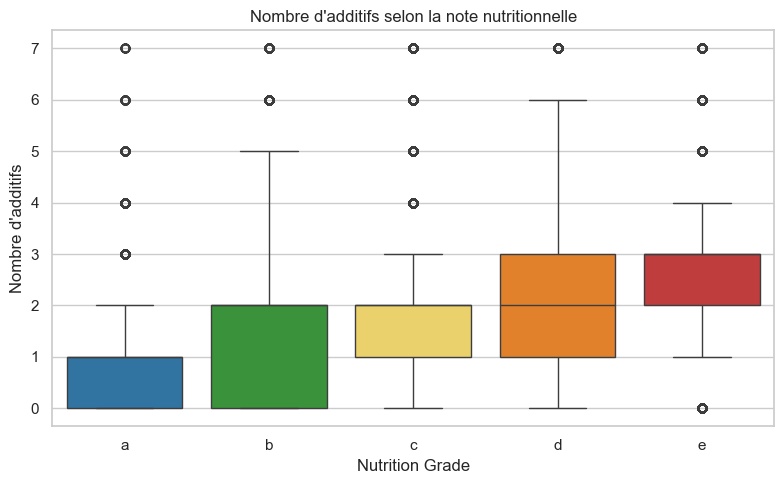

In [49]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x='nutrition_grade_fr',
    y='additives_n',
    order=grade_colors,
    palette=grade_colors
)

plt.title("Nombre d'additifs selon la note nutritionnelle")
plt.xlabel("Nutrition Grade")
plt.ylabel("Nombre d'additifs")
plt.tight_layout()
plt.show()

In [50]:
# groupby nutrition grade avec describe genre (mean, )
df.groupby("nutrition_grade_fr")[['additives_n', 'nutrition-score-fr_100g', 'energy_100g', 'saturated-fat_100g',
       'sugars_100g', 'salt_100g', 'fiber_100g', 'proteins_100g', 'carbohydrates_100g']].agg("mean")

,additives_n,nutrition-score-fr_100g,energy_100g,saturated-fat_100g,sugars_100g,salt_100g,fiber_100g,proteins_100g,carbohydrates_100g
nutrition_grade_fr,,,,,,,,,
a,0.845247,-3.549400,658.380818,0.548933,3.760410,0.345933,2.784790,6.723763,25.016692
b,1.730910,0.888115,512.571713,1.067764,4.541123,0.526888,1.263813,5.270051,17.052509
c,1.886957,5.302446,798.867668,2.264111,8.055589,0.773581,1.664451,6.626194,21.092651
d,2.182175,13.624510,1346.835211,6.358914,10.599002,1.088798,1.740202,8.502552,28.181322
e,2.744975,19.703723,1490.972753,9.092727,18.419929,0.824688,1.208837,6.213625,34.195501


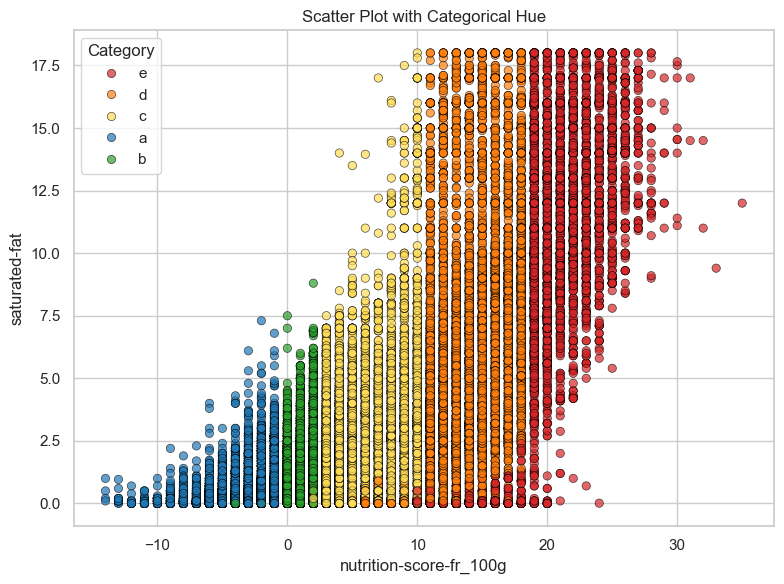

In [51]:
sns.set_theme(style="whitegrid")

# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    y='saturated-fat_100g',
    x='nutrition-score-fr_100g',      
    hue='nutrition_grade_fr',
    palette=grade_colors,
    alpha=0.7,
    edgecolor='black'
)

plt.title("Scatter Plot with Categorical Hue")
plt.ylabel("saturated-fat")
plt.xlabel("nutrition-score-fr_100g")
plt.legend(title='Category')
plt.tight_layout()
plt.show()

In [52]:
df_smapled = df.sample(n=10000)
# values_to_remove = [20.667975, 27.588198, 21.092651, 17.052509, 28.181322]

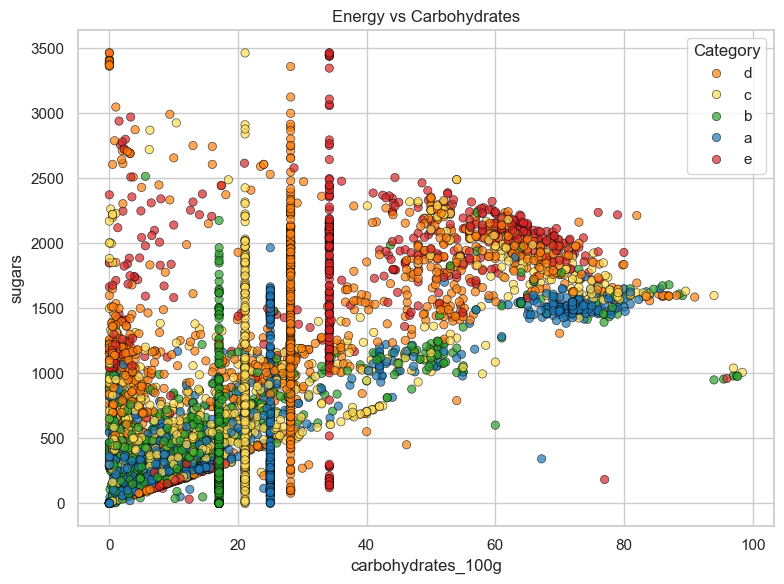

In [53]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_smapled,
    y='energy_100g',
    x='carbohydrates_100g',      
    hue='nutrition_grade_fr',
    palette=grade_colors,
    alpha=0.7,
    edgecolor='black'
)

plt.title("Energy vs Carbohydrates")
plt.ylabel("sugars")
plt.xlabel("carbohydrates_100g")
plt.legend(title='Category')
plt.tight_layout()
plt.show()

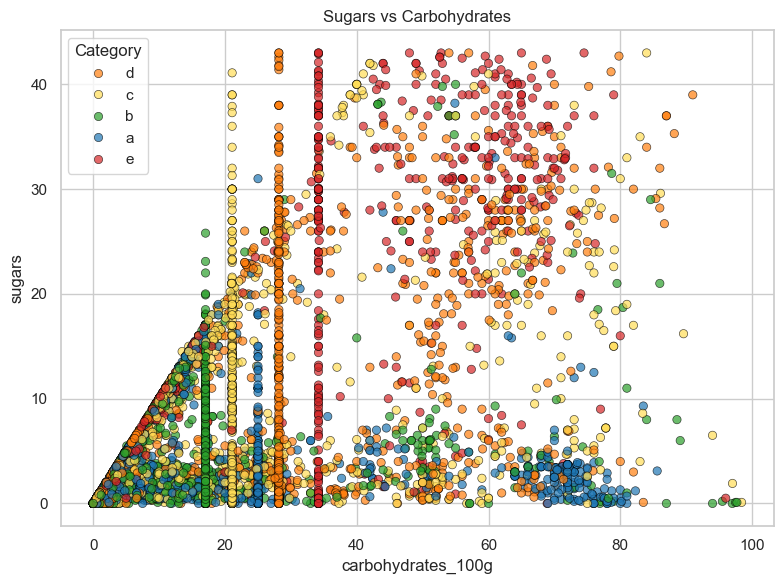

In [54]:
# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_smapled,
    y='sugars_100g',
    x='carbohydrates_100g',      
    hue='nutrition_grade_fr',
    palette=grade_colors,
    alpha=0.7,
    edgecolor='black'
)

plt.title("Sugars vs Carbohydrates")
plt.ylabel("sugars")
plt.xlabel("carbohydrates_100g")
plt.legend(title='Category')
plt.tight_layout()
plt.show()

# add markers for AB = good, C = moyen, DE = bad OU 
# cmap avec hot/cold

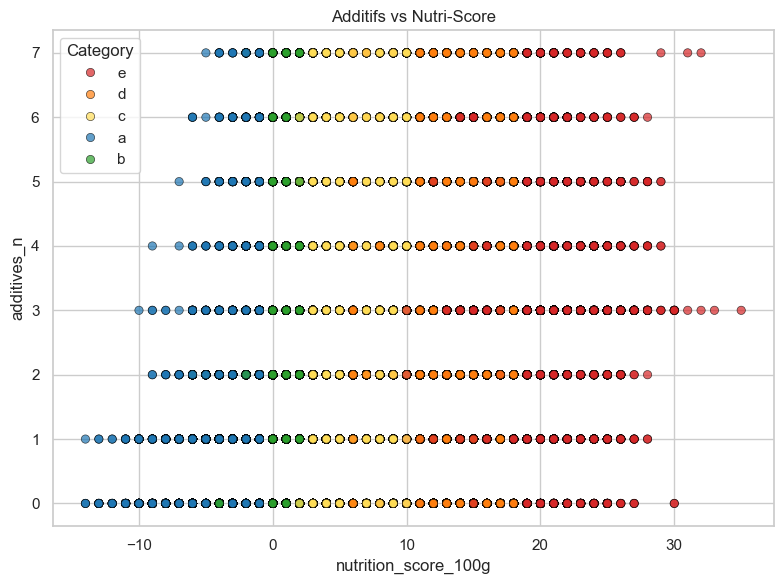

In [55]:
# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    y='additives_n',
    x='nutrition-score-fr_100g',      
    hue='nutrition_grade_fr',
    palette=grade_colors,
    alpha=0.7,
    edgecolor='black'
)

plt.title("Additifs vs Nutri-Score")
plt.ylabel("additives_n")
plt.xlabel("nutrition_score_100g")
plt.legend(title='Category')
plt.tight_layout()
plt.show()

C:\Users\jfurs\AppData\Local\Temp\ipykernel_22696\4107865229.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\jfurs\AppData\Local\Temp\ipykernel_22696\4107865229.py:22: UserWarning:

Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14



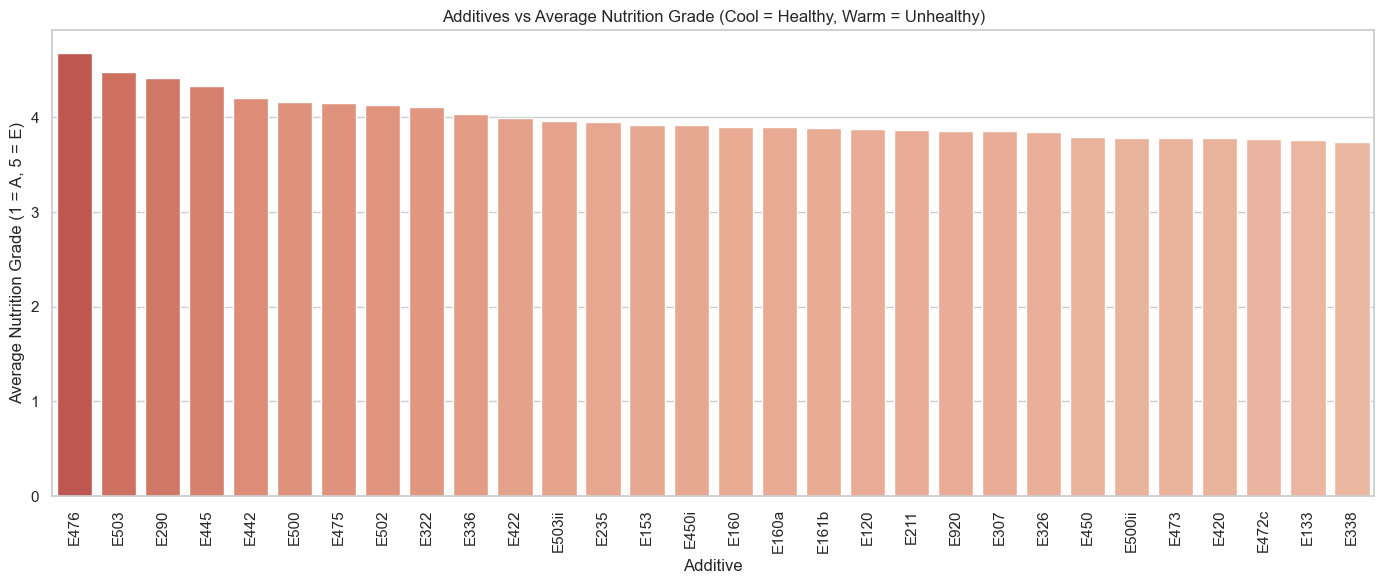

In [56]:
grade_mapping = {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5}
tmp_df = df.copy()
tmp_df['nutrition_grade_fr_num'] = tmp_df['nutrition_grade_fr'].map(grade_mapping)

df_clean = tmp_df.dropna(subset=['nutrition_grade_fr_num', 'additives'])
df_exploded = df_clean.explode('additives')

additive_stats = df_exploded.groupby('additives')['nutrition_grade_fr_num'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)
additive_stats = additive_stats[additive_stats['count'] >= 20]

additive_stats = additive_stats.reset_index()
additive_stats = additive_stats.sort_values(by='mean', ascending=False)

top_20 = additive_stats.head(30)

# Normalize grades for color mapping (1 to 5 → 0 to 1)
norm = (top_20['mean'] - 1) / 4  # (5-1)=4 range

colors = sns.color_palette("coolwarm", as_cmap=True)(norm)

plt.figure(figsize=(14, 6))
sns.barplot(
    x='additives',
    y='mean',
    data=top_20,
    palette=colors
)

plt.ylabel('Average Nutrition Grade (1 = A, 5 = E)')
plt.xlabel('Additive')
plt.title('Additives vs Average Nutrition Grade (Cool = Healthy, Warm = Unhealthy)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

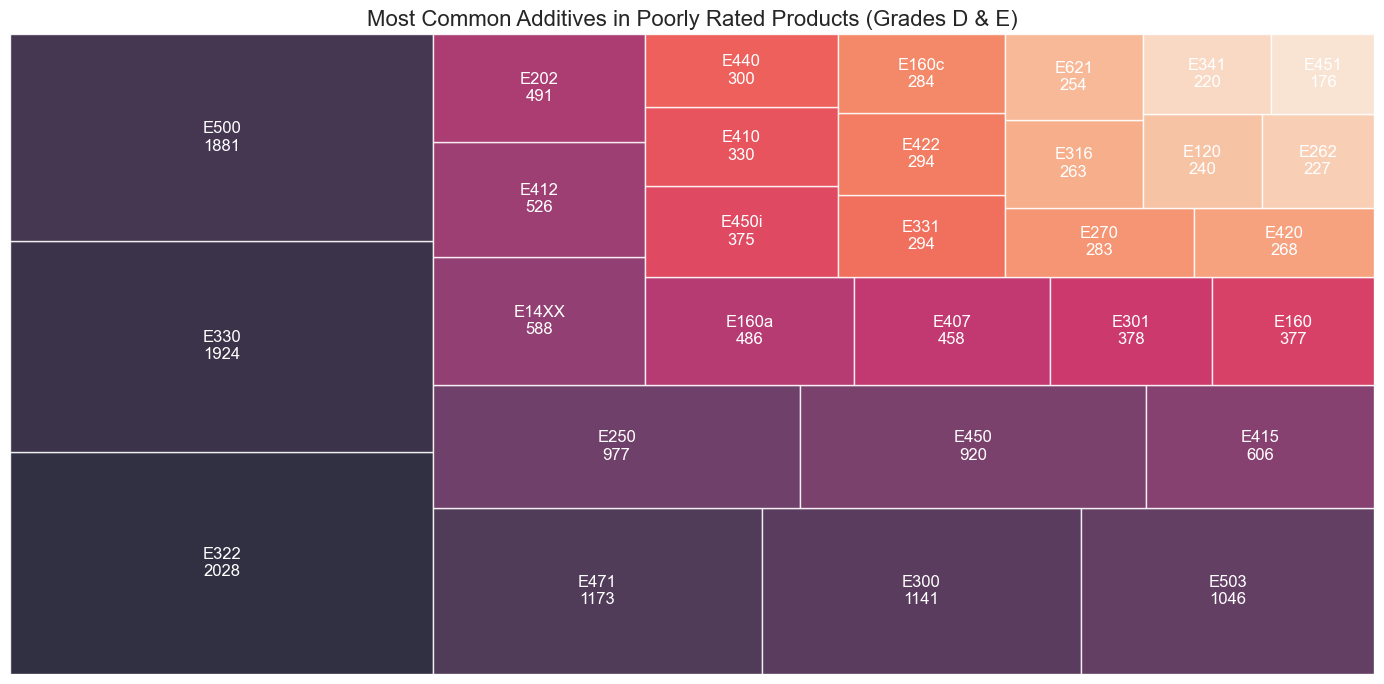

In [57]:
import matplotlib.pyplot as plt
import squarify

# Step 1: Filter for only 'd' and 'e' grades
tmp_df = df.copy()
tmp_df = tmp_df[tmp_df['nutrition_grade_fr'].isin(['d', 'e'])]

# Step 2: Drop rows without additive data
tmp_df = tmp_df.dropna(subset=['additives'])

# Step 3: Explode additive lists
tmp_df = tmp_df.explode('additives')

# Step 4: Count frequency of each additive
additive_counts = tmp_df['additives'].value_counts().reset_index()
additive_counts.columns = ['additive', 'count']

# Optional: Limit to top N for clarity
top_additives = additive_counts.head(30)

# Create labels with counts
labels = [f"{row['additive']}\n{row['count']}" for _, row in top_additives.iterrows()]

# Step 5: Plot a treemap with count annotations
plt.figure(figsize=(14, 7))
squarify.plot(
    sizes=top_additives['count'],
    label=labels,
    alpha=0.85,
    color=sns.color_palette("rocket", len(top_additives)),  # Optional custom color palette
    text_kwargs={'color': 'white'}
)
plt.axis('off')
plt.title('Most Common Additives in Poorly Rated Products (Grades D & E)', fontsize=16)
plt.tight_layout()
plt.show()


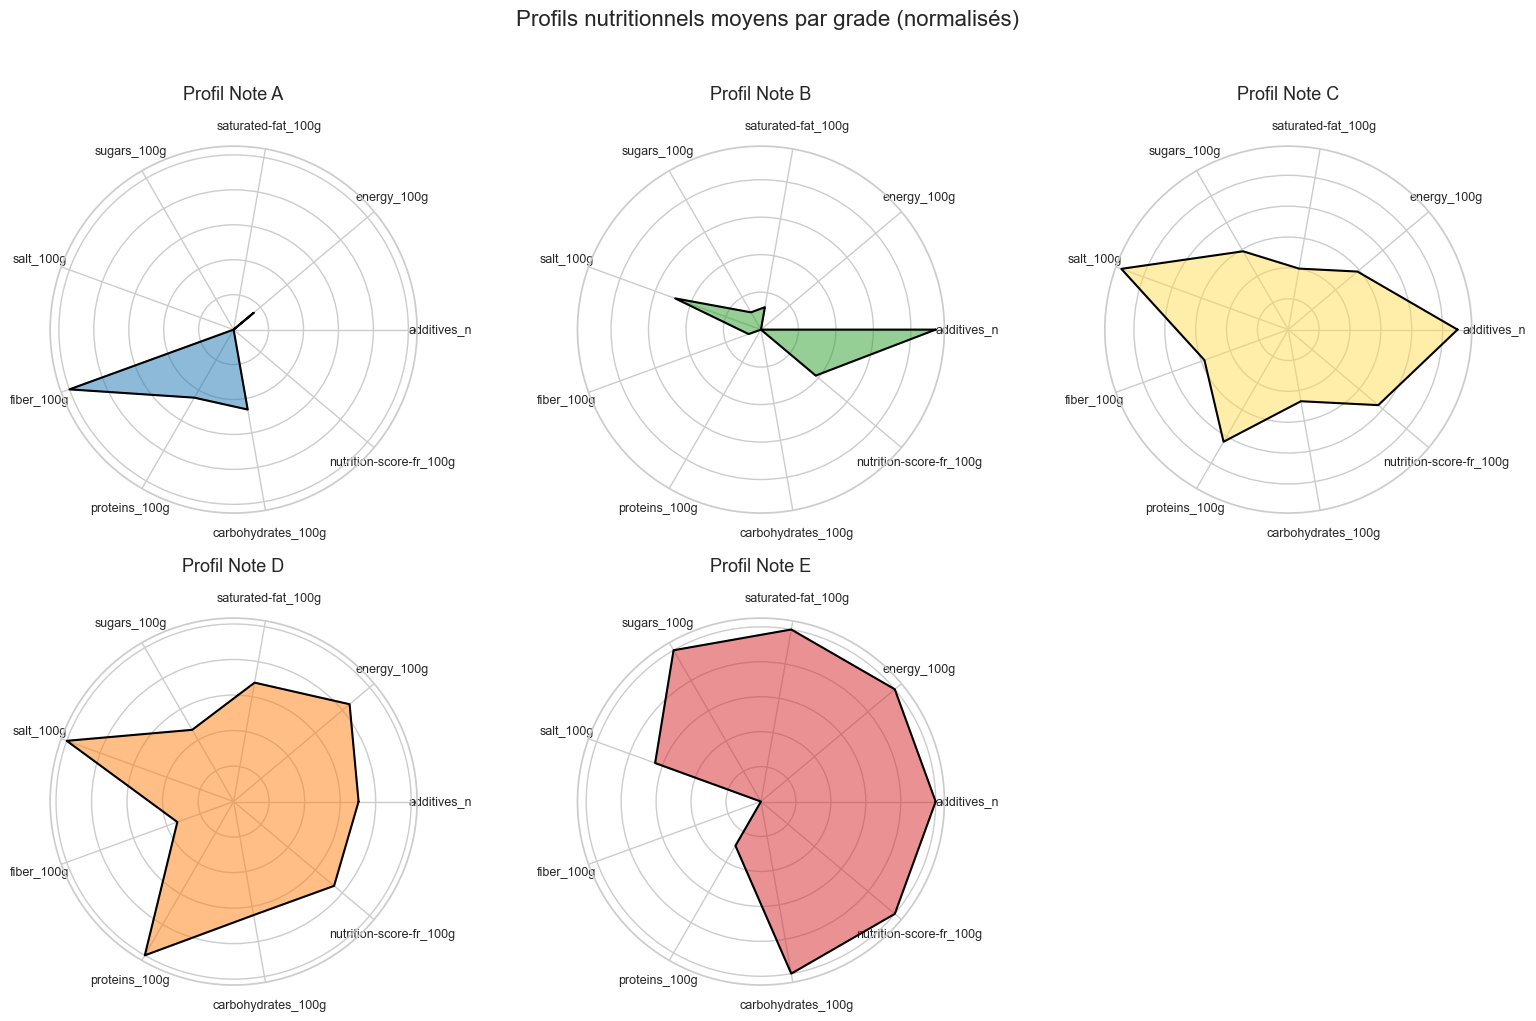

In [58]:
features = ['additives_n', 'energy_100g', 'saturated-fat_100g', 'sugars_100g',
            'salt_100g', 'fiber_100g', 'proteins_100g', 'carbohydrates_100g', 'nutrition-score-fr_100g']

df_avg = df.groupby('nutrition_grade_fr')[features].mean().dropna()
df_avg = df_avg.loc[sorted(df_avg.index)]

# df_qcut = df_avg.copy()
# for col in features:
#     df_qcut[col] = pd.qcut(df_avg[col], q=5, labels=False, duplicates='drop') / 4.0
# df_scaled = df_qcut

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_avg), columns=features, index=df_avg.index)

labels = features
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += [angles[0]]

fig, axes = plt.subplots(2, 3, subplot_kw=dict(polar=True), figsize=(16, 10))
axes = axes.flatten()

# Plot each grade
for i, (idx, row) in enumerate(df_scaled.iterrows()):
    values = row.tolist() + [row.tolist()[0]]
    ax = axes[i]
    
    color = grade_colors.get(idx.lower(), '#888888')  # fallback color

    ax.plot(angles, values, color='black', linewidth=1.5)
    ax.fill(angles, values, color=color, alpha=0.5)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticklabels([])
    ax.set_title(f"Profil Note {idx.upper()}", size=13, pad=15)

# Hide unused subplots if any
if len(df_scaled) < len(axes):
    for j in range(len(df_scaled), len(axes)):
        fig.delaxes(axes[j])

plt.suptitle("Profils nutritionnels moyens par grade (normalisés)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [59]:
df["Value"] = 1

df_cleaned = df.dropna(subset=['nutrition_grade_fr', 'pnns_groups_1'])

fig = px.sunburst(
    df_cleaned,
    path=['nutrition_grade_fr', 'pnns_groups_1'],
    values='Value',
    title="Catégories et Sous-catégories de produits pour chaque Nutri-Score"
)

fig.update_layout(
    margin=dict(t=40, l=0, r=0, b=0),
    width=800, 
    height=800, 
    # uniformtext=dict(minsize=12, mode='hide')
    )

fig.show()

# PCA

In [60]:
grade_mapping = {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5}
df = df.copy()
df['nutrition_grade_fr_num'] = df['nutrition_grade_fr'].map(grade_mapping)

In [61]:
num_cols = ['additives_n', 'nutrition-score-fr_100g', 'energy_100g',
       'saturated-fat_100g', 'sugars_100g', 'salt_100g', 'fiber_100g',
       'proteins_100g', "carbohydrates_100g", "nutrition_grade_fr_num"]

df_num = df[num_cols]

df_num = df_num.dropna(subset=["nutrition_grade_fr_num"])

In [62]:
X = df_num.values
X.shape

(44007, 10)

In [63]:
# Centrage / réduction des données pour que nos données soit à la même échelle !
std_scale = preprocessing.StandardScaler().fit(X)
X_scaled = std_scale.transform(X)

In [64]:
df_std = pd.DataFrame(X_scaled, columns=df_num.columns)
df_std

,additives_n,nutrition-score-fr_100g,energy_100g,saturated-fat_100g,sugars_100g,salt_100g,fiber_100g,proteins_100g,carbohydrates_100g,nutrition_grade_fr_num
0,0.110625,0.810786,-1.052756,-0.763679,0.192021,-1.003676,-1.055364,-1.132183,-0.640030,1.609715
1,0.110625,1.053962,0.215990,1.657440,-0.710679,0.125454,-0.223388,0.126747,0.173493,0.852155
2,0.720381,0.810786,-1.052756,-0.763679,0.192021,-0.894932,-0.336990,-1.132183,-0.640030,1.609715
3,1.939891,0.689197,1.370803,-0.213425,1.690117,-0.078623,-0.163961,-0.125039,1.400491,0.852155
4,1.939891,0.810786,1.185132,-0.213425,1.882181,-0.093200,0.014320,-0.158610,1.446242,0.852155
...,...,...,...,...,...,...,...,...,...,...
44002,1.939891,-0.526687,0.148474,-0.481949,-0.797107,-1.039244,-0.181789,-1.131511,3.244737,-0.662967
44003,0.110625,0.324432,1.729484,-0.015333,-0.633853,0.927186,2.272540,0.177105,-0.150824,0.094594
44004,0.110625,1.175551,0.223023,1.877542,0.201624,-0.617970,-1.055364,0.328176,0.173493,0.852155
44005,-0.499130,-1.256218,1.009308,-0.631618,-0.557028,-0.049470,2.450821,1.049963,2.306372,-1.420527


In [65]:
# determine what variables have the largest effect on the graph
pca = PCA()

# calculation loading scores and variation of each PC
pca.fit(X_scaled)

# génération des coordonnées pour le PCA graph
pca_data = pca.transform(X_scaled)

In [66]:
# calcul pourcentage de variation de chaque PC
per_var = np.round(pca.explained_variance_ratio_* 100, decimals=1)

# labels pour le plot
labels = ['PC' + str(x) for x in range(1, len(per_var)+1)]

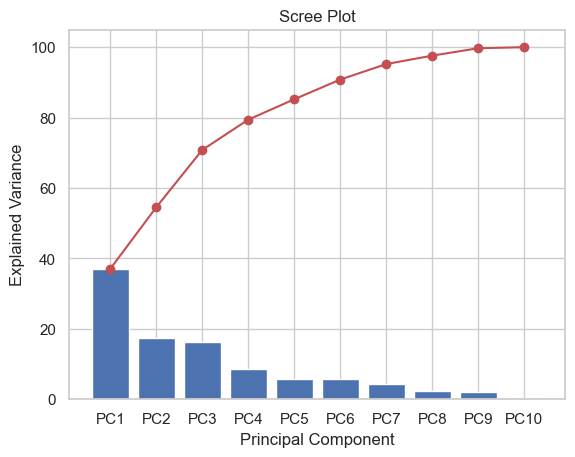

In [67]:
cumulative_variances = np.cumsum(per_var)

plt.bar(x=range(1,len(per_var)+1), height=per_var, tick_label = labels)
plt.plot(range(1, len(per_var)+1), cumulative_variances, marker='o', linestyle='-', color='r', label='Cumulative Explained Var')
plt.ylabel('Explained Variance')
plt.xlabel('Principal Component')
plt.title('Scree Plot')
plt.show()

In [68]:
print(f"PC1 et PC2 représentent {np.round(per_var[0] + per_var[1],2)} % de la variance expliquée donc un graph en 2D " + 
      "représentera relativement bien la donnée")

PC1 et PC2 représentent 54.5 % de la variance expliquée donc un graph en 2D représentera relativement bien la donnée


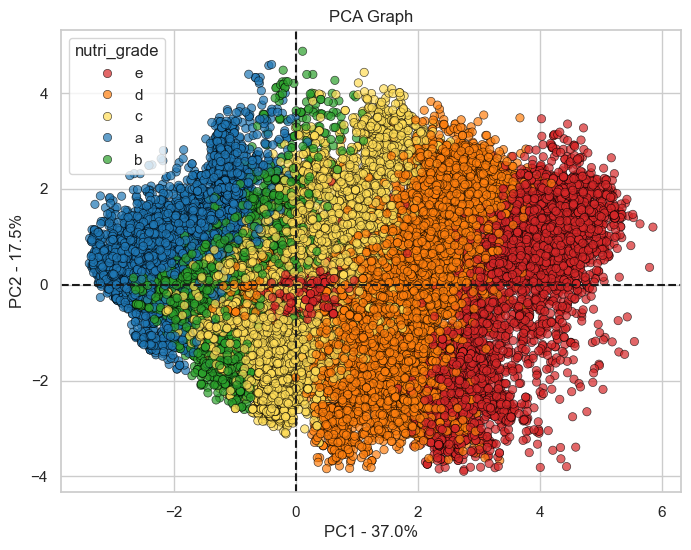

In [69]:
tmp_df = df.dropna(subset=["nutrition_grade_fr_num"])

pca_df = pd.DataFrame(pca_data, index=df_num.index, columns=labels)
pca_df["nutri_grade"] = tmp_df["nutrition_grade_fr"]

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='nutri_grade',
    palette=grade_colors,
    alpha=0.7,
    edgecolor='black'
)
plt.title('PCA Graph')
plt.xlabel(f'PC1 - {per_var[0]}%')
plt.ylabel(f'PC2 - {per_var[1]}%')
plt.axvline(x=0, color='k', linestyle='--')
plt.axhline(y=0, color='k', linestyle='--')

plt.show()

# hue de nutri score

In [70]:
all_ft = list(df_num.columns)

# determine which features had the largest influence on separating the clusters (soit PC1) 
loading_scores = pd.Series(pca.components_[0], index = all_ft)
sorted_scores = loading_scores.abs().sort_values(ascending=False)

print(sorted_scores)

nutrition-score-fr_100g    0.485074
nutrition_grade_fr_num     0.442256
saturated-fat_100g         0.411829
energy_100g                0.402181
sugars_100g                0.282586
carbohydrates_100g         0.238593
additives_n                0.214570
salt_100g                  0.193411
proteins_100g              0.130019
fiber_100g                 0.025013
dtype: float64


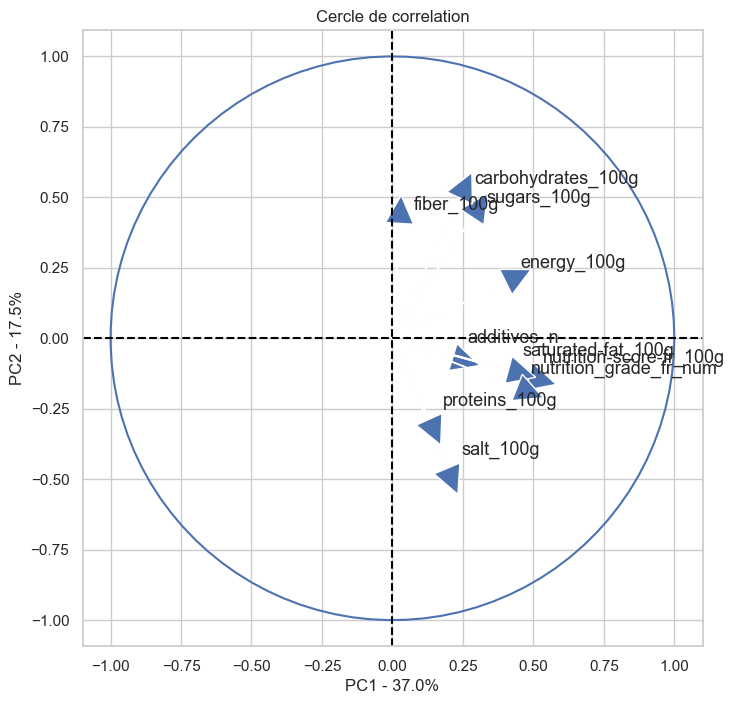

In [71]:
(fig, ax) = plt.subplots(figsize=(8, 8))
for i in range(0, pca.components_.shape[1]):
    ax.arrow(0,
             0,  # Start at origin
             pca.components_[0, i],  #0 for PC1
             pca.components_[1, i],  #1 for PC2
             head_width=0.1,
             head_length=0.1,
            #  color="black"
             )

    plt.text(pca.components_[0, i] + 0.05,
             pca.components_[1, i] + 0.05,
             df_num.columns.values[i],
             fontsize=13)

an = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(an), np.sin(an))
plt.axis('equal')
ax.set_title('Cercle de correlation')
plt.axhline(y=0,color='black',linestyle='--')
plt.axvline(x=0,color='black',linestyle='--')
plt.xlabel(f'PC1 - {per_var[0]}%')
plt.ylabel(f'PC2 - {per_var[1]}%')
plt.show()

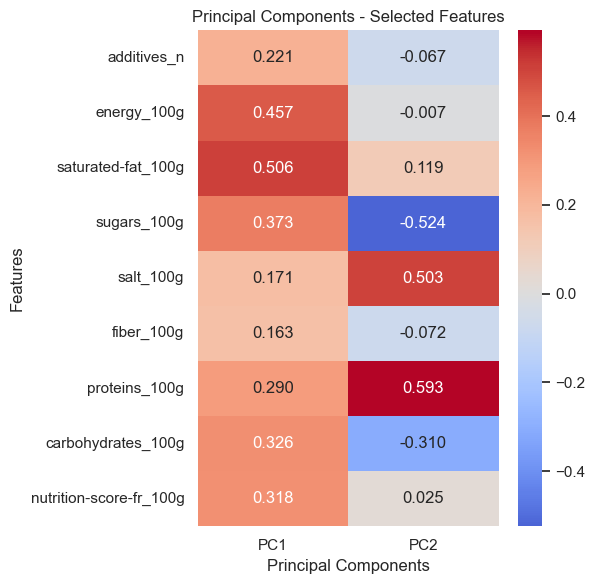

In [72]:
features = ['additives_n', 'energy_100g', 'saturated-fat_100g', 'sugars_100g',
            'salt_100g', 'fiber_100g', 'proteins_100g', 'carbohydrates_100g', 'nutrition-score-fr_100g']

tmp_df = df[features]

x = MinMaxScaler().fit_transform(tmp_df)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(x)
loadings = pca.components_.T 
loadings_df = pd.DataFrame(loadings, index=features, columns=[f'PC{i+1}' for i in range(loadings.shape[1])])

plt.figure(figsize=(6, 6))
sns.heatmap(loadings_df, annot=True, cmap='coolwarm', center=0, fmt=".3f")
plt.title('Principal Components - Selected Features')
plt.xlabel('Principal Components')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Tests

In [73]:
# Exemple avec une régression
data = df[['additives_n', 'nutrition-score-fr_100g', 'energy_100g',
           'saturated-fat_100g', 'sugars_100g', 'salt_100g', 'fiber_100g',
           'proteins_100g', 'carbohydrates_100g', 'nutrition_grade_fr_num']]

data = data.dropna()

# Separate X and y again
X = data.drop(columns='nutrition_grade_fr_num')
y = data['nutrition_grade_fr_num']

X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()
print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     nutrition_grade_fr_num   R-squared:                       0.911
Model:                                OLS   Adj. R-squared:                  0.911
Method:                     Least Squares   F-statistic:                 4.994e+04
Date:                    Tue, 18 Nov 2025   Prob (F-statistic):               0.00
Time:                            14:14:22   Log-Likelihood:                -21473.
No. Observations:                   44007   AIC:                         4.297e+04
Df Residuals:                       43997   BIC:                         4.305e+04
Df Model:                               9                                         
Covariance Type:                nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [74]:
# test chi2 sur pnn et nutri_grade
contingence = pd.crosstab(df['pnns_groups_2'], df['nutrition_grade_fr'])

chi2, p, dof, expected = chi2_contingency(contingence)

print("Statistique chi² :", chi2)
print("Degrés de liberté :", dof)
print("Valeur p :", p)

alpha = 0.05
if p < alpha:
    print("Il y a une association significative entre le sous-groupe alimentaire et la note nutritionnelle.")
else:
    print("Pas d'association significative détectée.")

Statistique chi² : 32538.605100643483
Degrés de liberté : 152
Valeur p : 0.0
Il y a une association significative entre le sous-groupe alimentaire et la note nutritionnelle.


In [75]:
contingence = pd.crosstab(df['pnns_groups_1'], df['nutrition_grade_fr'])

chi2, p, dof, expected = chi2_contingency(contingence)

print("Statistique chi² :", chi2)
print("Degrés de liberté :", dof)
print("Valeur p :", p)

alpha = 0.05
if p < alpha:
    print("Il y a une association significative entre le groupe alimentaire et la note nutritionnelle.")
else:
    print("Pas d'association significative détectée.")

Statistique chi² : 18838.11988858003
Degrés de liberté : 44
Valeur p : 0.0
Il y a une association significative entre le groupe alimentaire et la note nutritionnelle.


In [76]:
t_cols = ['additives_n', 'nutrition-score-fr_100g', 'energy_100g',
           'saturated-fat_100g', 'sugars_100g', 'salt_100g', 'fiber_100g',
           'proteins_100g', 'carbohydrates_100g']

results = []

for col in t_cols:
    temp_data = data[[col, 'nutrition_grade_fr_num']].dropna()

    res = pg.kruskal(dv=col, between='nutrition_grade_fr_num', data=temp_data)

    row = {
        'variable': col,
        'H': res['H'].values[0],
        'p-unc': res['p-unc'].values[0]
    }

    results.append(row)

final_df = pd.DataFrame(results)

final_df = final_df.sort_values(by='p-unc')
print(final_df)

                  variable             H  p-unc
0              additives_n   7311.327452    0.0
1  nutrition-score-fr_100g  41165.584380    0.0
2              energy_100g  10405.192200    0.0
3       saturated-fat_100g  14819.226360    0.0
4              sugars_100g   5025.706985    0.0
5                salt_100g   5491.507061    0.0
6               fiber_100g   5750.518169    0.0
7            proteins_100g   1558.177969    0.0
8       carbohydrates_100g   2835.618948    0.0


In [77]:
cols = ['additives_n', 'nutrition-score-fr_100g', 'energy_100g',
           'saturated-fat_100g', 'sugars_100g', 'salt_100g', 'fiber_100g',
           'proteins_100g', 'carbohydrates_100g', 'nutrition_grade_fr_num']

# tests : coefficient de corr Pearson
colonnes_a_tester = data[cols]

# Corrélation pairwise uniquement sur ces colonnes
corrs = pg.pairwise_corr(colonnes_a_tester, method='pearson')
corrs

,X,Y,method,alternative,n,r,CI95%,p-unc,BF10,power
0,additives_n,nutrition-score-fr_100g,pearson,two-sided,44007,0.352354,"[0.34, 0.36]",0.000000e+00,inf,1.000000
1,additives_n,energy_100g,pearson,two-sided,44007,0.149013,"[0.14, 0.16]",6.836801e-217,2.179e+212,1.000000
2,additives_n,saturated-fat_100g,pearson,two-sided,44007,0.211245,"[0.2, 0.22]",0.000000e+00,inf,1.000000
3,additives_n,sugars_100g,pearson,two-sided,44007,0.238064,"[0.23, 0.25]",0.000000e+00,inf,1.000000
4,additives_n,salt_100g,pearson,two-sided,44007,0.154242,"[0.15, 0.16]",2.051496e-232,7.004e+227,1.000000
5,additives_n,fiber_100g,pearson,two-sided,44007,-0.088296,"[-0.1, -0.08]",6.979858e-77,3.648e+72,1.000000
6,additives_n,proteins_100g,pearson,two-sided,44007,-0.040272,"[-0.05, -0.03]",2.879782e-17,1.93e+13,1.000000
7,additives_n,carbohydrates_100g,pearson,two-sided,44007,0.089570,"[0.08, 0.1]",4.530983e-79,5.539e+74,1.000000
8,additives_n,nutrition_grade_fr_num,pearson,two-sided,44007,0.341573,"[0.33, 0.35]",0.000000e+00,inf,1.000000
9,nutrition-score-fr_100g,energy_100g,pearson,two-sided,44007,0.585585,"[0.58, 0.59]",0.000000e+00,inf,1.000000


### Tests for graphs

In [78]:
resultats = []

for col in cols:
    series = df[col].dropna()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        test = pg.normality(series)

    test['variable'] = col
    resultats.append(test)

resultats_normalite = pd.concat(resultats, ignore_index=True)

resultats_normalite = resultats_normalite[['variable', 'W', 'pval', 'normal']]
print(resultats_normalite)

# pas de tests de pearson car rien ne suit une distribution normale

                  variable         W           pval  normal
0              additives_n  0.837626  9.292762e-121   False
1  nutrition-score-fr_100g  0.924419  4.707350e-100   False
2              energy_100g  0.891124  1.088828e-109   False
3       saturated-fat_100g  0.727592  6.866889e-136   False
4              sugars_100g  0.703843  2.028301e-138   False
5                salt_100g  0.908657  5.352684e-105   False
6               fiber_100g  0.824734  6.174883e-123   False
7            proteins_100g  0.845470  2.337065e-119   False
8       carbohydrates_100g  0.854177  9.967652e-118   False
9   nutrition_grade_fr_num  0.901464   9.672158e-94   False


In [79]:
pg.corr(data['nutrition-score-fr_100g'], data['additives_n'], method='spearman')

# La corrélation est positive :
# quand le score nutritionnel augmente (ce qui signifie une moins bonne qualité nutritionnelle),
# le nombre d’additifs a tendance à augmenter aussi.

,n,r,CI95%,p-val,power
spearman,44007,0.398153,"[0.39, 0.41]",0.0,1.0


In [80]:
pg.corr(data['saturated-fat_100g'], data['nutrition-score-fr_100g'], method='spearman')
# C’est une corrélation positive forte à très forte.
# La teneur en graisses saturées est un facteur très important qui dégrade le score nutritionnel.

,n,r,CI95%,p-val,power
spearman,44007,0.658402,"[0.65, 0.66]",0.0,1.0


In [81]:
pg.corr(data['energy_100g'], data['carbohydrates_100g'], method='spearman')
# corrélation positive modérée à forte
# Les aliments plus riches en glucides tendent à être plus caloriques.

,n,r,CI95%,p-val,power
spearman,44007,0.583477,"[0.58, 0.59]",0.0,1.0


In [82]:
pg.corr(data['sugars_100g'], data['carbohydrates_100g'], method='spearman')
# Il existe une relation positive modérée entre les glucides totaux et les sucres.
# les aliments qui ont plus de glucides ont tendance à contenir plus de sucres, 
# mais la relation n’est pas parfaite : certains aliments riches en glucides peuvent être peu sucrés (par exemple les féculents).

,n,r,CI95%,p-val,power
spearman,44007,0.444056,"[0.44, 0.45]",0.0,1.0
